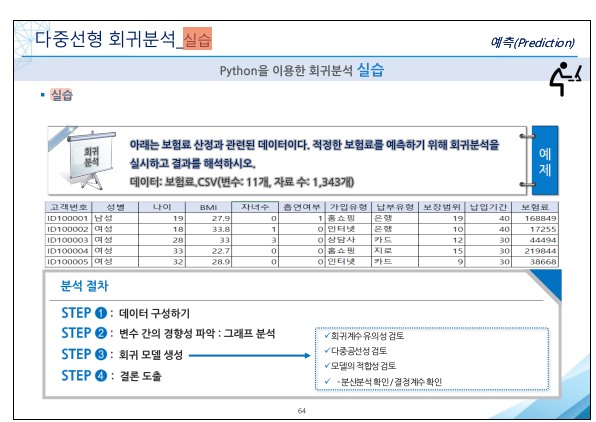

### STEP 0 패키지 불러오기

In [1]:
# 45 Page
# 데이터 구성:Series, DataFrame
import pandas as pd
# 행렬 연산
import numpy as np
# 데이터 시각화
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
# 선형 회귀모델 formula(y ~ X1 + X2 + ...)
import statsmodels.formula.api as smf
# 잔차의 정규성 확인 :qqplot, 회귀분석의 상수항 추가 : add_constant
from statsmodels.api import qqplot, add_constant
# 다중공선성 확인
from statsmodels.stats.outliers_influence import variance_inflation_factor
# 학습용/평가용 데이터 분리:train, test
from sklearn.model_selection import train_test_split
# 선형회귀모형
from sklearn.linear_model import LinearRegression
# 변수 선택법(후진제거법)
from sklearn.feature_selection import RFE
# Scale 변환->표준화 회귀계수 산출
from sklearn.preprocessing import StandardScaler
# 평가함수
from sklearn.metrics import r2_score

### STEP 0 한글 폰트 적용

In [2]:
import matplotlib

# 맑은 고딕 적용
# 한글 폰트 설정 (Windows 기준 - 맑은 고딕)
plt.rc('font', family='Malgun Gothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
# 음수 표시
matplotlib.rc("axes", unicode_minus = False)

In [3]:
# 실행결과 경고메시지 출력 제외
import warnings

warnings.filterwarnings('ignore')

### STEP ❶ 데이터 구성하기

[데이터 로드 → 결측치 처리 → 단위 변환 → 불필요 변수 제거 → 더미화]

In [ ]:
# 파일 불러오기
df_raw = pd.read_csv(r"D:\BigData_수업용\yay-20260525T102121Z-3-001\yay\2. Big Data 분석 실습파일\보험료.csv", encoding='euc-kr')
df_raw.head()

,고객번호,성별,나이,BMI,자녀수,흡연여부,가입유형,납부유형,보장범위,납입기간,보험료
0,ID100001,남성,19,27.9,0,1,홈쇼핑,은행,19,40,168849
1,ID100002,여성,18,33.8,1,0,인터넷,은행,10,40,17255
2,ID100003,여성,28,33.0,3,0,상담사,카드,12,30,44494
3,ID100004,여성,33,22.7,0,0,홈쇼핑,지로,15,30,219844
4,ID100005,여성,32,28.9,0,0,인터넷,카드,9,30,38668


In [6]:
# 결측치 확인
df_raw.isnull().sum()

고객번호    0
성별      0
나이      0
BMI     0
자녀수     0
흡연여부    0
가입유형    2
납부유형    3
보장범위    0
납입기간    0
보험료     0
dtype: int64

결측치(있어야하는데 없는 값) 존재  
가입유형 2, 납부유형 3

In [7]:
# 결측치 처리
# 가입유형의 최빈값으로 채우기
mode_join = df_raw['가입유형'].mode()[0]
df_raw['가입유형'] = df_raw['가입유형'].fillna(mode_join)

# 납부유형의 최빈값으로 채우기
mode_pay = df_raw['납부유형'].mode()[0]
df_raw['납부유형'] = df_raw['납부유형'].fillna(mode_pay)

단위 분리(split) 및 타입 변환(astype)할 데이터 없음

In [8]:
#  단위를 나타내는 항목 제외
# 고객번호'라는 이름이 붙은 세로 기둥 전체를 삭제
df_raw = df_raw.drop(['고객번호'], axis=1)
# 옵션 : axis=1 : 열(Column) 방향입니다
# 옵션 : axis=0 : 행(Row) 방향입니다. (기본값)

In [9]:
# 범주형 변수의 더미화(get_dummies)
# 문자열 컬럼들을 모두 숫자로 변환
# drop_first=True는 '성별_남성'이 0이면 자동으로 여성이므로, 중복 정보를 줄이기 위해 사용합니다.
df_raw_dummy = pd.get_dummies(df_raw, drop_first=True)

# 최종 결과 확인
print(df_raw_dummy.head())
print(df_raw_dummy.info()) # 모든 컬럼이 숫자형(int, float, uint8)인지 확인

   나이   BMI  자녀수  흡연여부  보장범위  납입기간     보험료  성별_여성  가입유형_인터넷  가입유형_홈쇼핑  \
0  19  27.9    0     1    19    40  168849      0         0         1   
1  18  33.8    1     0    10    40   17255      1         1         0   
2  28  33.0    3     0    12    30   44494      1         0         0   
3  33  22.7    0     0    15    30  219844      1         0         1   
4  32  28.9    0     0     9    30   38668      1         1         0   

   납부유형_지로  납부유형_카드  
0        0        0  
1        0        0  
2        0        1  
3        1        0  
4        0        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1343 entries, 0 to 1342
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   나이        1343 non-null   int64  
 1   BMI       1343 non-null   float64
 2   자녀수       1343 non-null   int64  
 3   흡연여부      1343 non-null   int64  
 4   보장범위      1343 non-null   int64  
 5   납입기간      1343 non-null   int64  
 6   보험료  

In [10]:
# 요약통계량
df_raw.describe().round(3)

,나이,BMI,자녀수,흡연여부,보장범위,납입기간,보험료
count,1343.000,1343.000,1343.000,1343.000,1343.000,1343.000,1343.000
mean,39.186,30.666,1.093,0.205,11.575,28.220,132549.095
std,14.072,6.091,1.206,0.404,2.532,6.095,121072.476
min,18.000,16.000,0.000,0.000,8.000,20.000,11218.000
25%,26.000,26.300,0.000,0.000,10.000,20.000,47196.000
50%,39.000,30.400,1.000,0.000,11.000,30.000,93779.000
75%,51.000,34.700,2.000,0.000,12.000,30.000,166220.500
max,64.000,53.100,5.000,1.000,20.000,40.000,637704.000


### STEP ❷ 변수 간의 경향성 파악 – 그래프 분석

목표변수 (Y, 종속변수): 최종적으로 맞추고 싶은 정답입니다. 이 문제에서는 '적정한 보험료를 예측'하는 것이 목적이므로, 보험료가 목표변수입니다.

설명변수 (X, 독립변수): 정답을 맞히기 위해 필요한 힌트들입니다. 나이, BMI, 자녀수, 흡연여부 등이 모두 설명변수가 됩니다.

회귀 분석의 약속: 원인(설명변수)을 x, 결과(목표변수)를 y에 둡니다.   
df.plot.scatter 함수는 기본적으로 x축 하나, y축 하나

<Axes: xlabel='나이', ylabel='보험료'>

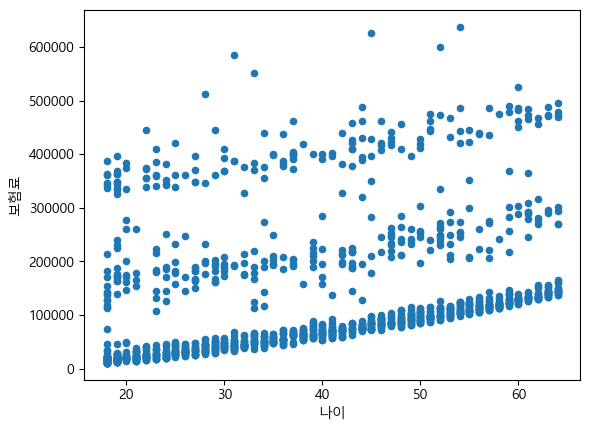

In [11]:
# 목표변수와 설명변수의 산점도
df_raw.plot.scatter(x = "나이", y = "보험료")

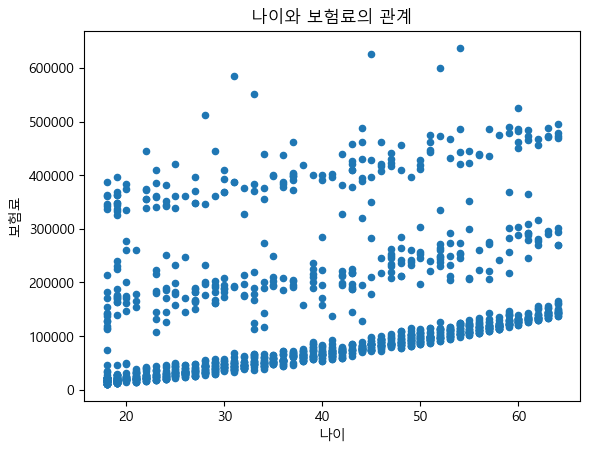

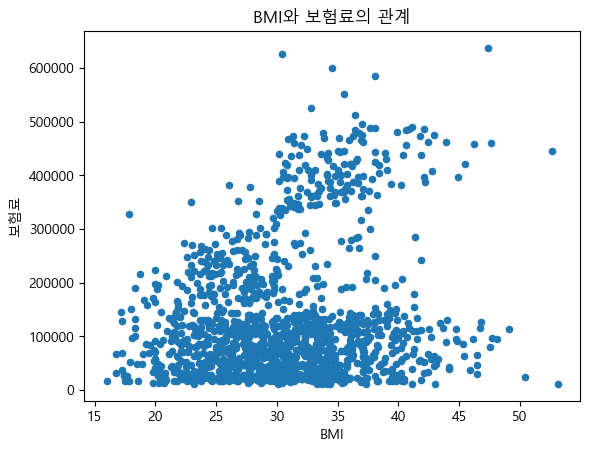

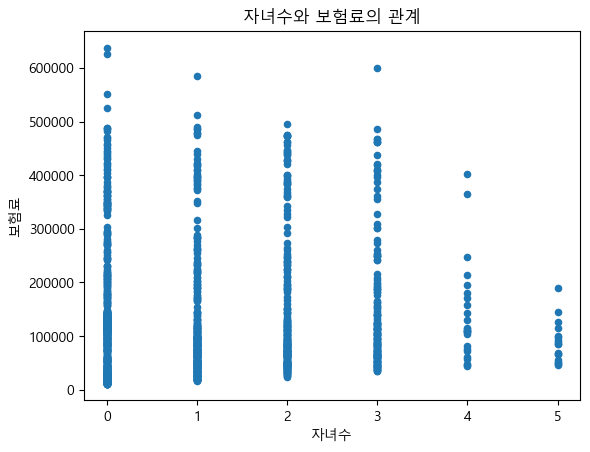

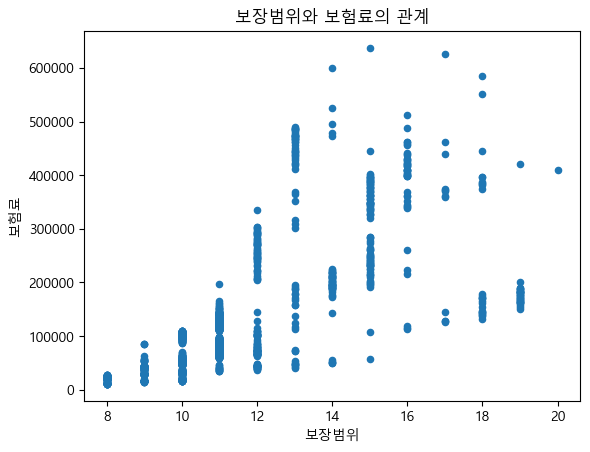

In [12]:
# 설명변수 리스트
features = ["나이", "BMI", "자녀수", "보장범위"]

for col in features:
    df_raw.plot.scatter(x = col, y = "보험료")
    plt.title(f"{col}와 보험료의 관계")
    plt.show()

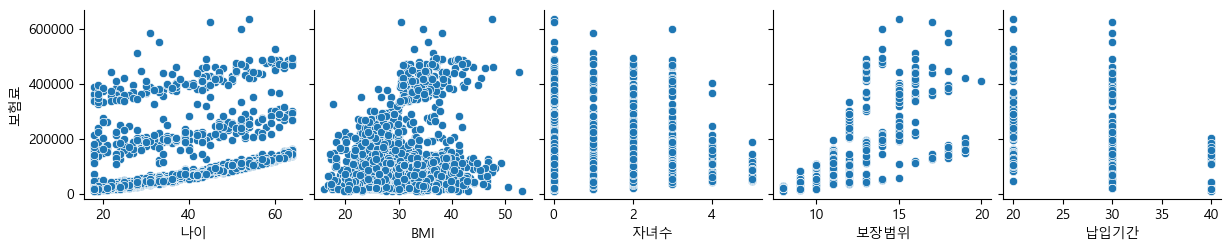

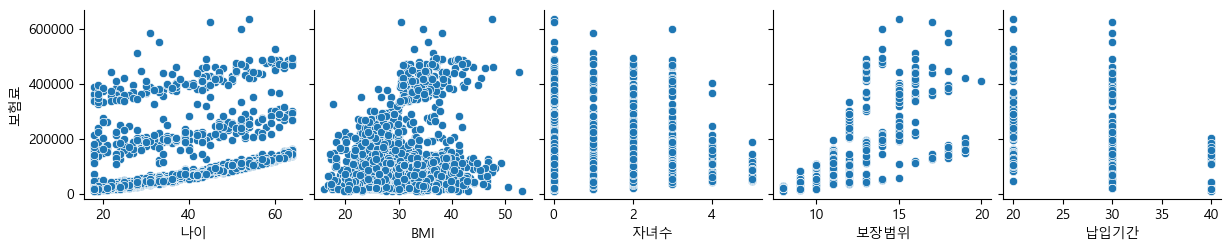

In [13]:
# 산점도 행렬:목표변수와 설명변수 지정
sns.pairplot(df_raw_dummy, y_vars="보험료", x_vars=["나이", "BMI", "자녀수", "보장범위", "납입기간"])

# 회귀 적합선 추가 : kind ="reg" 
sns.pairplot(df_raw_dummy, y_vars="보험료", x_vars=["나이", "BMI", "자녀수", "보장범위", "납입기간"])

plt.show()

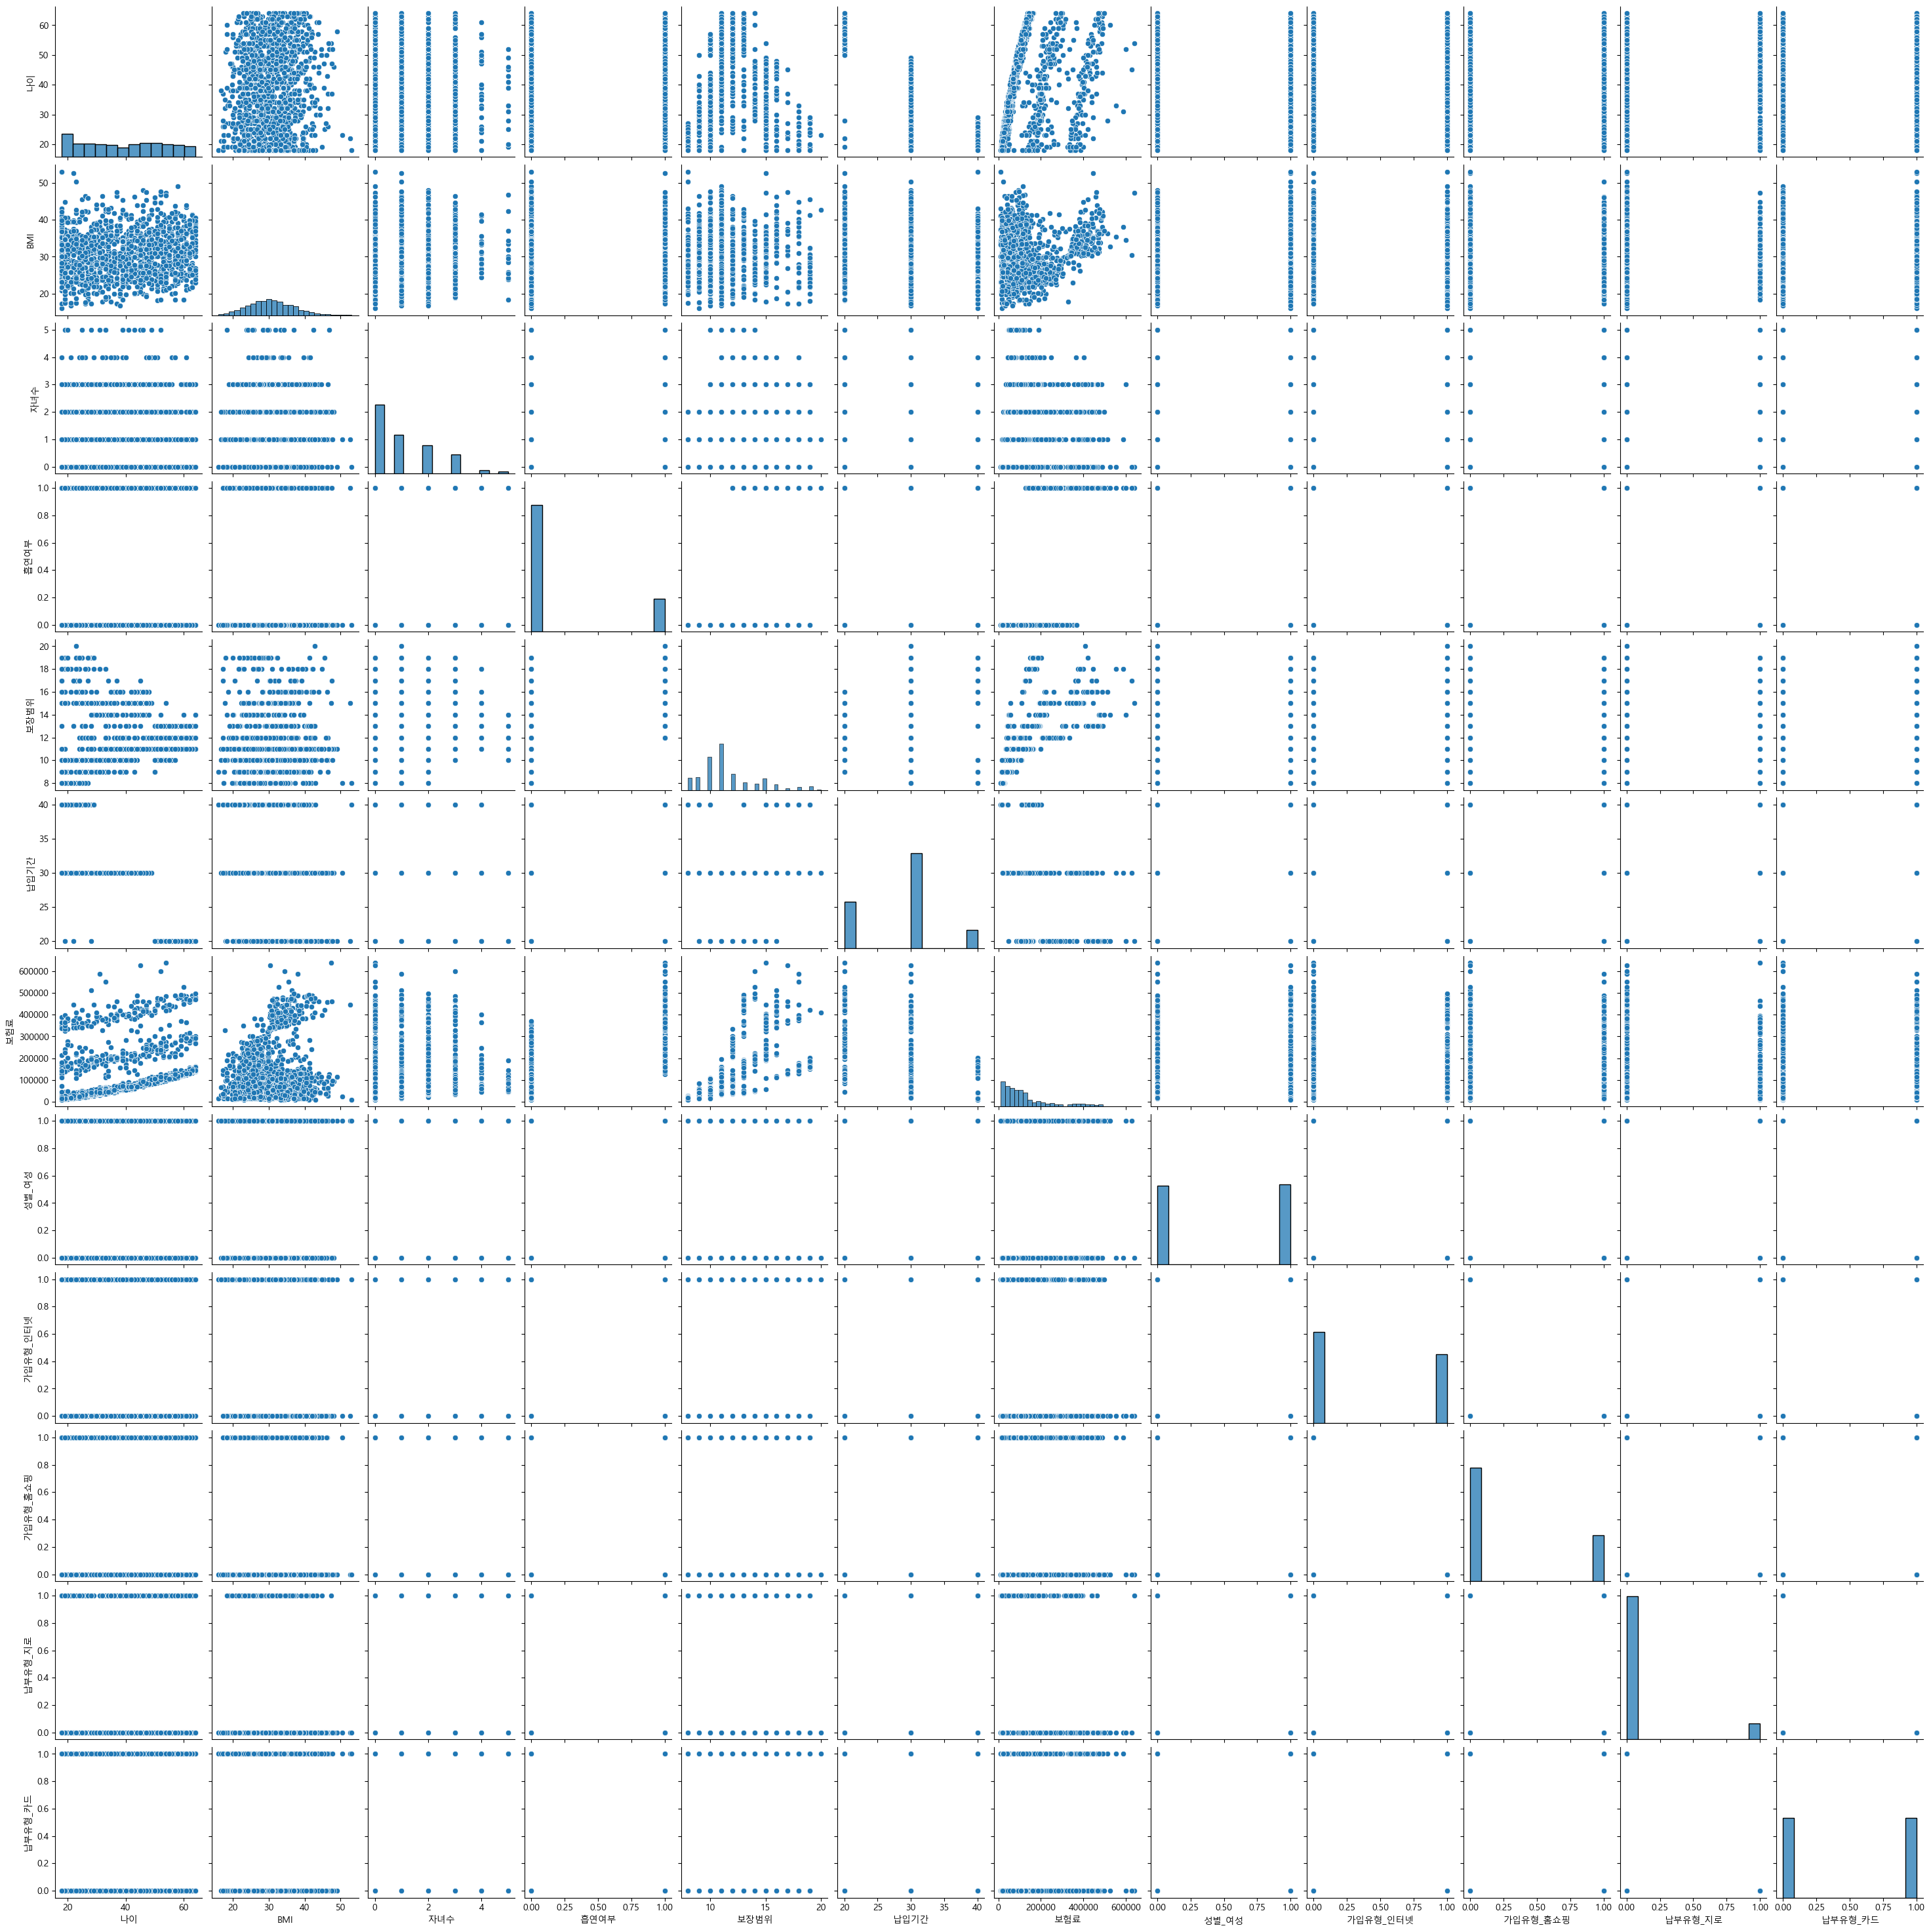

In [14]:
# 산점도 행렬:전체 숫자형 변수
sns.pairplot(df_raw_dummy)

In [15]:
# 상관계수 확인 (수치형 변수들 간의 관계)
# 문자열 컬럼이 포함된 df_raw 대신 숫자로 변환된 df_raw_dummy를 사용합니다.
df_raw.corr(method = "pearson").round(3)        
# corr은 Correlation(상관관계)
# 피어슨(Pearson) 상관계수라는 가장 표준적인 계산 방식

,나이,BMI,자녀수,흡연여부,보장범위,납입기간,보험료
나이,1.000,0.108,0.045,-0.021,-0.019,-0.826,0.302
BMI,0.108,1.000,0.013,0.003,0.015,-0.139,0.198
자녀수,0.045,0.013,1.000,0.007,0.188,-0.039,0.068
흡연여부,-0.021,0.003,0.007,1.000,0.701,0.045,0.788
보장범위,-0.019,0.015,0.188,0.701,1.000,0.144,0.704
납입기간,-0.826,-0.139,-0.039,0.045,0.144,1.000,-0.283
보험료,0.302,0.198,0.068,0.788,0.704,-0.283,1.000


### STEP ❸ 회귀 모델 생성

In [16]:
# 선형 회귀 분석 : formula(y ~ X1 + X2 + ...) 이용. 상수항(Intercept)은 자동으로 추가됨
reg_model = smf.ols(formula = "보험료 ~ 나이", data = df_raw)
reg_result = reg_model.fit()
print(reg_result.summary())

                            OLS Regression Results                            
Dep. Variable:                    보험료   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     134.5
Date:                Mon, 25 May 2026   Prob (F-statistic):           1.07e-29
Time:                        22:38:51   Log-Likelihood:                -17560.
No. Observations:                1343   AIC:                         3.512e+04
Df Residuals:                    1341   BIC:                         3.513e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3.077e+04   9325.588      3.300      0.0

나이의 P>|t|가  0.000임  => 나이는 보험료에 확실히 영향을 준다.  
R-squared:                       0.091 => 나이가 보험료 변동의 약 9.1퍼센트를 설명한다는 뜻입니다.

##### 예측은...?
표 중간의 coef (계수) 컬럼을 보면 예측 방정식을 만들 수 있습니다.  
Intercept (절편): $3.077 \times 10^4$ (약 30,770원) -> 나이가 0살일 때의 기본 베이스 금액입니다.  
나이: 2597.3088 -> 나이가 1살 많아질 때마다 보험료가 약 2,597원씩 올라간다는 뜻입니다.

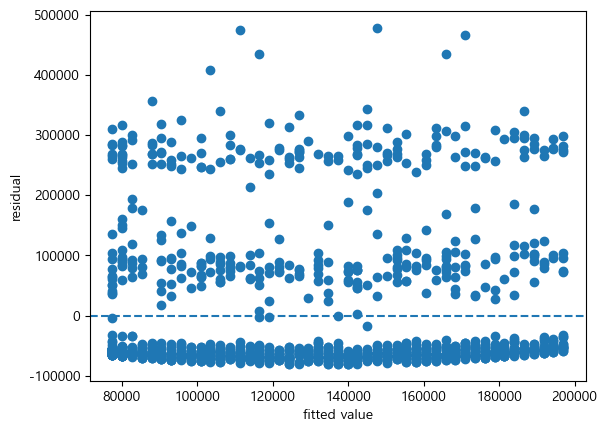

In [17]:
# 잔차 산점도: X-예측값, Y-잔차 
plt.scatter(reg_result.fittedvalues, reg_result.resid)
plt.xlabel("fitted value"); plt.ylabel("residual")
plt.axhline(y = 0, linestyle = "--")

1. 잔차 산점도 (등분산성 검토)  

보는 법: 점들이 0을 기준으로 위아래에 아무런 패턴 없이 무작위로 흩어져 있어야 합니다.  

분석: 현재 그래프를 보면 점들이 특정 구간에 뭉쳐 있거나 깔때기 모양으로 퍼지는 경향이 아주 심하지는 않습니다. 하지만 0보다 한참 위에 있는 점(잔차가 큰 값)들이 꽤 보이죠? 이는 모델이 예측하지 못한 '비싼 보험료' 데이터가 많다는 뜻입니다.

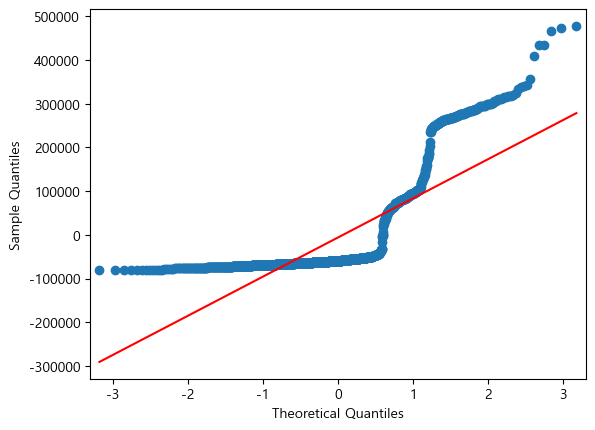

In [18]:
# 잔차 정규성 검정:Q-Q plot. s-standardized line, 
#  r-regression line, q-quartiles
qqplot(reg_result.resid, line = "q")
plt.show()

2. 잔차 정규성 검정 (Q-Q plot)  

보는 법: 파란 점들이 빨간 대각선 위에 예쁘게 올라타 있어야 잔차가 정규분포를 따른다고 봅니다.  

분석: 지금 그래프는 S자 형태로 휘어지면서 빨간 선을 많이 벗어나 있습니다. 특히 양쪽 끝이 심하게 들려 있죠?  

결론: "잔차의 정규성 가정을 만족하지 못한다"고 판단합니다. 즉, 나이 하나만으로는 설명되지 않는 특이한 데이터(이상치)가 많다는 신호입니다.

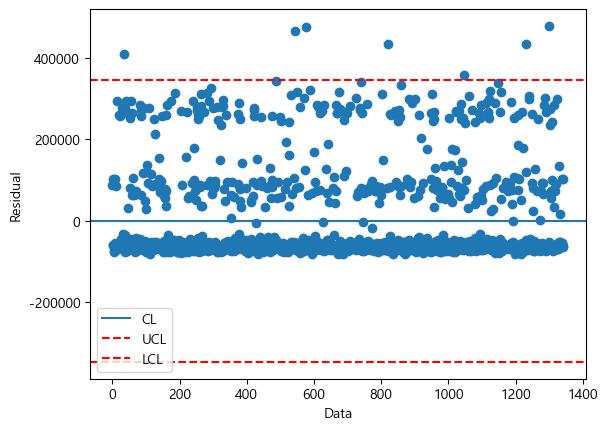

In [19]:
# 잔차의 독립성 확인
plt.scatter(df_raw.index, reg_result.resid, marker="o")
plt.xlabel("Data") ; plt.ylabel("Residual")
plt.axhline(y=0,linestyle="-", label='CL')
plt.axhline(y=3*np.std(reg_result.resid),linestyle="--",color="red",label='UCL' )
plt.axhline(y=-3*np.std(reg_result.resid),linestyle="dashed",color="red",label='LCL')
plt.legend() ; plt.show()

3. 잔차의 독립성 확인 (관리도)  

보는 법: 점들이 시간 순서(Data Index)에 따라 어떤 흐름(예: 점점 커짐)이 없어야 하고, 빨간 점선(UCL, LCL) 밖으로 나가는 점이 거의 없어야 합니다.

분석: 대부분의 데이터가 0 근처에 잘 모여 있지만, 위쪽 빨간 점선(UCL)을 뚫고 나가는 점들이 꽤 보입니다.

결론: 데이터 간의 순서에 따른 상관관계는 없어 보이지만(독립성 만족), 예측 범위를 크게 벗어나는 데이터들이 존재함을 알 수 있습니다.

### 결론 !!! 보험료에 영향을 주는 다른 중요한 변수가 있는 것으로 판단된다  
### -> 다중 회귀 분석이 필요하다.

### STEP ❸ 회귀 모델 생성

In [20]:
# 상관관계 분석
df_raw_dummy.corr().round(3)

,나이,BMI,자녀수,흡연여부,보장범위,납입기간,보험료,성별_여성,가입유형_인터넷,가입유형_홈쇼핑,납부유형_지로,납부유형_카드
나이,1.000,0.108,0.045,-0.021,-0.019,-0.826,0.302,-0.018,-0.020,-0.018,-0.003,-0.023
BMI,0.108,1.000,0.013,0.003,0.015,-0.139,0.198,0.046,-0.020,-0.025,0.017,0.001
자녀수,0.045,0.013,1.000,0.007,0.188,-0.039,0.068,0.021,-0.012,-0.028,-0.026,0.022
흡연여부,-0.021,0.003,0.007,1.000,0.701,0.045,0.788,0.075,-0.086,0.058,0.002,-0.001
보장범위,-0.019,0.015,0.188,0.701,1.000,0.144,0.704,-0.005,-0.092,0.064,0.025,0.001
납입기간,-0.826,-0.139,-0.039,0.045,0.144,1.000,-0.283,0.055,0.028,0.007,0.012,0.003
보험료,0.302,0.198,0.068,0.788,0.704,-0.283,1.000,0.058,-0.097,0.048,0.015,0.001
성별_여성,-0.018,0.046,0.021,0.075,-0.005,0.055,0.058,1.000,0.014,-0.027,-0.005,0.035
가입유형_인터넷,-0.020,-0.020,-0.012,-0.086,-0.092,0.028,-0.097,0.014,1.000,-0.549,-0.005,-0.002
가입유형_홈쇼핑,-0.018,-0.025,-0.028,0.058,0.064,0.007,0.048,-0.027,-0.549,1.000,0.111,-0.064


## 보는 법 !!
1. 목표변수(보험료)와의 상관관계 분석표에서 '보험료' 행(또는 열)을 가로로 쭉 따라가며 숫자가 큰 것을 찾습니다.  

흡연여부 (0.788): 가장 높은 수치입니다. 보험료와 매우 강한 양(+)의 상관관계가 있습니다. 즉, 흡연을 하면 보험료가 크게 올라간다는 강력한 힌트입니다.  

보장범위 (0.704): 두 번째로 높습니다. 보장해 주는 범위가 넓을수록 보험료가 비싸진다는 당연한 논리가 수치로 증명됩니다.  

나이 (0.302): 어느 정도 관련이 있지만, 흡연이나 보장범위보다는 영향력이 작습니다.

납입기간 (-0.283): 음(-)의 상관관계입니다. 납입기간이 길어질수록(할부 개념) 매달 내는 보험료는 조금씩 낮아질 수 있다는 점을 시사합니다.  

2. 설명변수 간의 상관관계 (다중공선성 확인)  
이 부분이 다중선형 회귀에서 매우 중요합니다. 힌트들끼리 너무 비슷하면 모델이 헷갈려 하는데, 이를 다중공선성이라고 합니다.  

흡연여부 vs 보장범위 (0.701): 두 변수의 상관계수가 0.7 이상으로 꽤 높습니다. 이는 흡연자가 보통 더 넓은 보장범위를 선택하는 경향이 있거나, 데이터상 두 항목이 밀접하게 연결되어 있음을 뜻합니다.  

나이 vs 납입기간 (-0.826): 주의 깊게 보셔야 할 부분입니다. 상관계수가 -0.8을 넘을 정도로 매우 강합니다. 나이가 많을수록 납입기간을 짧게 가져가는 등의 패턴이 강해서, 다중 회귀 모델을 만들 때 이 두 변수를 동시에 넣으면 모델이 불안정해질 수 있습니다.  

In [21]:
# train/test data 분리
df_train, df_test = train_test_split(df_raw_dummy, test_size = 0.3, random_state = 1234) 
print("train data size : {}".format(df_train.shape))
print("test data size : {}".format(df_test.shape))

train data size : (940, 12)
test data size : (403, 12)


In [22]:
# 선형 회귀 분석 : formula(y ~ X1 + X2 + ...) 이용. 상수항(Intercept) 자동 추가. 코드 중간에서 줄 바꿈 “\” 추가
reg_model = smf.ols(formula = "보험료 ~ 나이 + BMI + 자녀수 + 흡연여부 + 보장범위 + 납입기간 + \
                    성별_여성 + 가입유형_인터넷 + 가입유형_홈쇼핑 + 납부유형_지로 + 납부유형_카드", \
                    data = df_raw_dummy)
# 적합
reg_result = reg_model.fit()
print(reg_result.summary())

                            OLS Regression Results                            
Dep. Variable:                    보험료   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     536.5
Date:                Mon, 25 May 2026   Prob (F-statistic):               0.00
Time:                        22:38:54   Log-Likelihood:                -16487.
No. Observations:                1343   AIC:                         3.300e+04
Df Residuals:                    1331   BIC:                         3.306e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -5.77e+04   2.04e+04     -2.825      0.0

### 해설...

1. 모델의 설명력 (R-squared)  
R-squared: 0.816 * 해석: 이 모델의 설명력은 약 81.6%입니다. 나이 하나만 썼을 때(9.1%)보다 훨씬 정확해졌습니다. 즉, 현재 넣은 변수들이 보험료의 변동을 매우 잘 설명하고 있다는 뜻입니다.  

2. 변수들의 유의성 (P>|t|)  
이 부분이 가장 중요합니다. 값이 0.05보다 작아야 통계적으로 의미가 있는 변수입니다.  

유의미한 변수 (보험료에 영향 있음): 나이(0.001), BMI(0.000), 흡연여부(0.000), 보장범위(0.000), 납입기간(0.000), 성별_여성(0.013)  

유의미하지 않은 변수 (보험료에 영향 없음): 자녀수(0.081), 가입유형_인터넷(0.546), 가입유형_홈쇼핑(0.710), 납부유형_지로(0.546)  

분석: 자녀수나 가입/납부 유형은 현재 모델에서 보험료를 결정하는 데 유의미한 힌트가 되지 못하고 있습니다.  

3. 영향력의 크기와 방향 (coef)  
흡연여부 (1.622e+05): 계수 값이 약 162,200으로 가장 압도적입니다. 다른 조건이 같을 때, 흡연자가 비흡연자보다 보험료가 약 16만 원 정도 더 비싸다는 것을 의미합니다.  

BMI (2813.5): 체질량지수가 1 올라갈 때마다 보험료가 약 2,813원씩 상승합니다.  

납입기간 (-5617.2): 음(-)의 관계입니다. 납입기간이 1단위 길어질수록 보험료는 약 5,617원씩 낮아집니다.  

4. 다중공선성 주의보  
아까 상관관계 분석에서 나이와 납입기간의 상관계수가 -0.826으로 매우 높았던 것 기억하시나요?  
현재 결과를 보면 두 변수 모두 유의미(P < 0.05)하게 나오긴 했지만, 계수(coef)값이 우리가 예상한 것보다 튀거나 표준 오차(std err)가 커질 수 있습니다. 실습 보고서에는 "나이와 납입기간 간의 높은 상관관계로 인해 다중공선성 검토가 필요함"이라고 언급해주면 높은 점수를 받을 수 있습니다.  

In [23]:
# 1. 설명변수 데이터 생성 (목표변수인 '보험료'만 제외)
df_raw_x = df_raw_dummy.drop('보험료', axis = 1)

# 2. 모든 데이터를 수치형(float)으로 변환 (더미 변수 포함)
df_raw_x = df_raw_x.astype(float)

# 3. statsmodels에서 회귀 분석 시 필요한 상수항(Intercept) 추가
df_raw_x_const = add_constant(df_raw_x)

# 4. VIF를 저장할 데이터프레임 구성
df_vif = pd.DataFrame()
df_vif["variable"] = df_raw_x_const.columns
df_vif["VIF"] = [variance_inflation_factor(df_raw_x_const.values, i) \
                 for i in range(df_raw_x_const.shape[1])]

# 5. VIF 기준 오름차순 정렬 및 결과 출력
# 보통 VIF가 10 이상이면 다중공선성이 있다고 판단합니다.
df_vif.sort_values("VIF", ascending = True).round(2)

,variable,VIF
2,BMI,1.03
7,성별_여성,1.03
3,자녀수,1.09
11,납부유형_카드,1.13
10,납부유형_지로,1.14
8,가입유형_인터넷,1.45
9,가입유형_홈쇼핑,1.47
4,흡연여부,2.14
5,보장범위,2.34
1,나이,3.34


수치가 다 낮다!!!

### 해설

네, 아주 훌륭한 결과입니다! 결론부터 말씀드리면 "모든 변수의 다중공선성 문제가 없다"고 판단할 수 있습니다.

해석 포인트 세 가지를 정리해 드릴게요.

1. VIF 수치 해석 (합격점)
기준점: 보통 통계학에서는 VIF가 10 이상이면 "문제가 심각하다", 5 이상이면 "주의가 필요하다"고 봅니다.

현재 상태: 모든 변수의 VIF가 3.5 이하입니다. 아까 걱정했던 '나이(3.34)'와 '납입기간(3.50)'도 기준치인 10에 한참 못 미치기 때문에, 모델에 한꺼번에 넣고 분석해도 수학적으로 아무런 문제가 없습니다.

2. 변수 간의 독립성 확인
나이와 납입기간: 아까 상관관계 분석에서 이 두 변수가 서로 매우 강하게 엮여 있는 것(-0.826)을 확인했었죠? 그래서 VIF가 높게 나올까 봐 걱정했는데, 3.5 정도면 모델이 두 변수의 차이를 충분히 구분해서 학습할 수 있는 수준입니다. 안심하고 사용하셔도 됩니다.

3. const (상수항)의 VIF
주의: 맨 아래 const가 206.00으로 매우 높게 나와서 놀라셨을 수도 있는데, 이는 정상입니다.

이유: const는 변수가 아니라 모델의 기본 베이스(절편)를 잡기 위해 넣은 가상의 값입니다. 상수항의 VIF는 분석 대상이 아니니 그냥 무시하시면 됩니다.

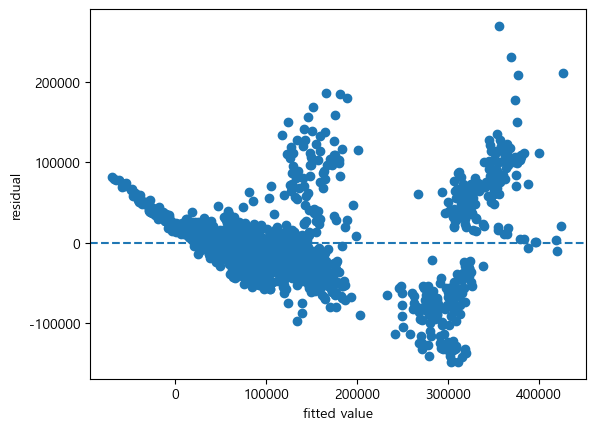

In [24]:
# 잔차 산점도: X-예측값, Y-잔차 
plt.scatter(reg_result.fittedvalues, reg_result.resid)
plt.xlabel("fitted value")
plt.ylabel("residual")
plt.axhline(y = 0, linestyle = "--")

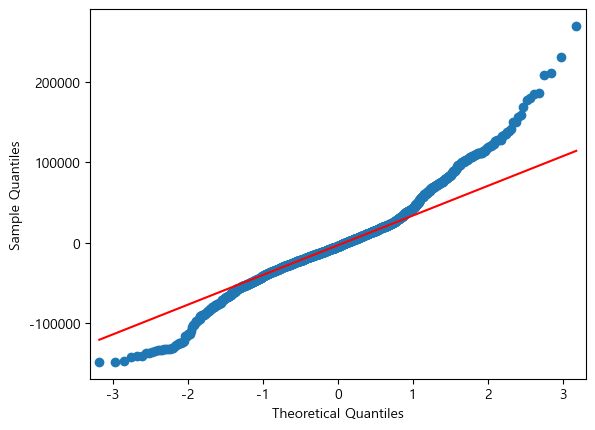

In [25]:
# 잔차 정규성 검정:Q-Q plot. s-standardized line, 
#  r-regression line, q-quartiles
qqplot(reg_result.resid, line = "q")
plt.show()

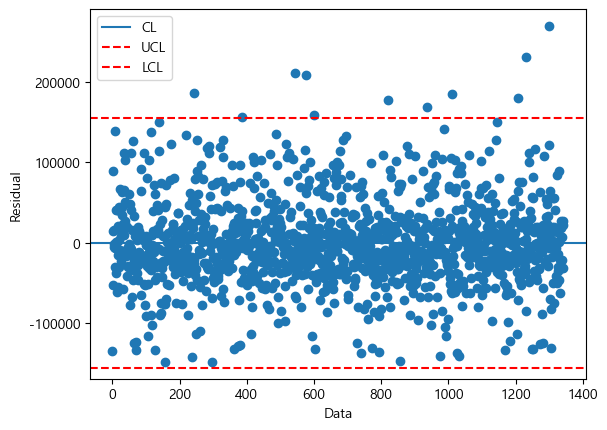

In [26]:
# 59 Page
# 잔차의 독립성 확인
plt.scatter(df_raw.index, reg_result.resid)
plt.xlabel("Data")  ;  plt.ylabel("Residual")
plt.axhline(y=0,linestyle="-", label='CL')
plt.axhline(y=3*np.std(reg_result.resid),linestyle="--",color="red",label='UCL' )
plt.axhline(y=-3*np.std(reg_result.resid),linestyle="dashed",color="red",label='LCL')
plt.legend()

잔차의 독립성 확인 결과, 대부분의 잔차가 관리 한계선(UCL, LCL) 내에 무작위로 분포하여 독립성 가정을 만족함. 다만, 일부 이상치(Outlier)가 확인되어 모델의 정규성에 영향을 주고 있으므로, 향후 분석 시 해당 데이터에 대한 개별 검토가 필요함

결과가 랜덤하고 벗어나는 점이 없으면 독립성을 만족한다.  
잔차가 y=0기준으로 관리 상/하한을 벗어나지 않고 Random하게 산포되어 있어야 독립성 만족


#### 해결 방법

- 저 튀는 점들이 누구인지 찾아서 삭제하고 다시 돌린다.
- 보험료에 로그($log$)를 취해서 격차를 줄인다

In [27]:
# 잔차의 절대값이 큰 순서대로 상위 10개 추출
# 어떤 고객들이 모델의 예측을 크게 벗어났는지 확인합니다.
outliers = df_raw_dummy.copy()
outliers['residual'] = reg_result.resid
outliers['abs_resid'] = outliers['residual'].abs()

# 잔차 절대값 기준 내림차순 정렬
top_outliers = outliers.sort_values(by='abs_resid', ascending=False).head(10)
print(top_outliers)

      나이   BMI  자녀수  흡연여부  보장범위  납입기간     보험료  성별_여성  가입유형_인터넷  가입유형_홈쇼핑  \
1300  45  30.4    0     1    17    30  625928      1         0         0   
1230  52  34.5    3     1    14    20  600213      1         0         0   
543   54  47.4    0     1    15    20  637704      0         0         0   
577   31  38.1    1     1    18    30  585710      0         0         1   
242   55  26.8    1     0    13    20  351601      0         1         0   
1012  61  33.3    4     0    13    20  365802      0         1         0   
1206  59  34.8    2     0    13    20  369106      0         0         0   
819   33  35.5    0     1    18    30  551354      0         0         1   
936   44  29.7    2     0    15    30  321086      1         0         0   
599   52  37.5    2     0    12    20  334719      0         0         0   

      납부유형_지로  납부유형_카드       residual      abs_resid  
1300        0        0  269730.707410  269730.707410  
1230        0        0  231171.032844  231171.032844 

1. 범인 분석 (왜 모델이 당황했나?)
인덱스 1300번 (가장 큰 잔차: 약 269,730):

데이터: 나이 45세, BMI 30.4, 흡연여부 1, 보장범위 17, 납입기간 30.

보험료: 625,928원

분석: 비슷한 조건의 다른 사람들보다 보험료가 압도적으로 높습니다. 모델은 공식에 따라 약 35만 원 정도로 예측했는데, 실제는 62만 원이 넘게 나온 거죠. 이 분은 아마 데이터에 기록되지 않은 '과거 병력'이 있거나 아주 특수한 고가 상품에 가입했을 가능성이 큽니다.

인덱스 1230, 543번:

이들도 보험료가 60만 원대입니다.

보통 이 모델에서 보험료가 60만 원을 넘으려면 나이가 아주 많거나 모든 조건이 최악이어야 하는데, 이들은 40~50대임에도 불구하고 보험료가 비정상적으로 높게 측정되어 있습니다.

## 결론  
이상치 분석 결과, 실제 보험료가 50만 원을 초과하는 고액 가입자 데이터에서 큰 잔차가 발생함을 확인하였음. 이는 현재의 설명변수(나이, BMI 등)만으로는 설명되지 않는 '고객의 병력'이나 '특수 담보' 등의 요인이 고액 가입자군에 존재함을 시사함. 모델의 범용성을 높이기 위해 해당 이상치를 제거하거나, 고액 가입자를 위한 별도의 모델 분리가 필요할 것으로 판단됨

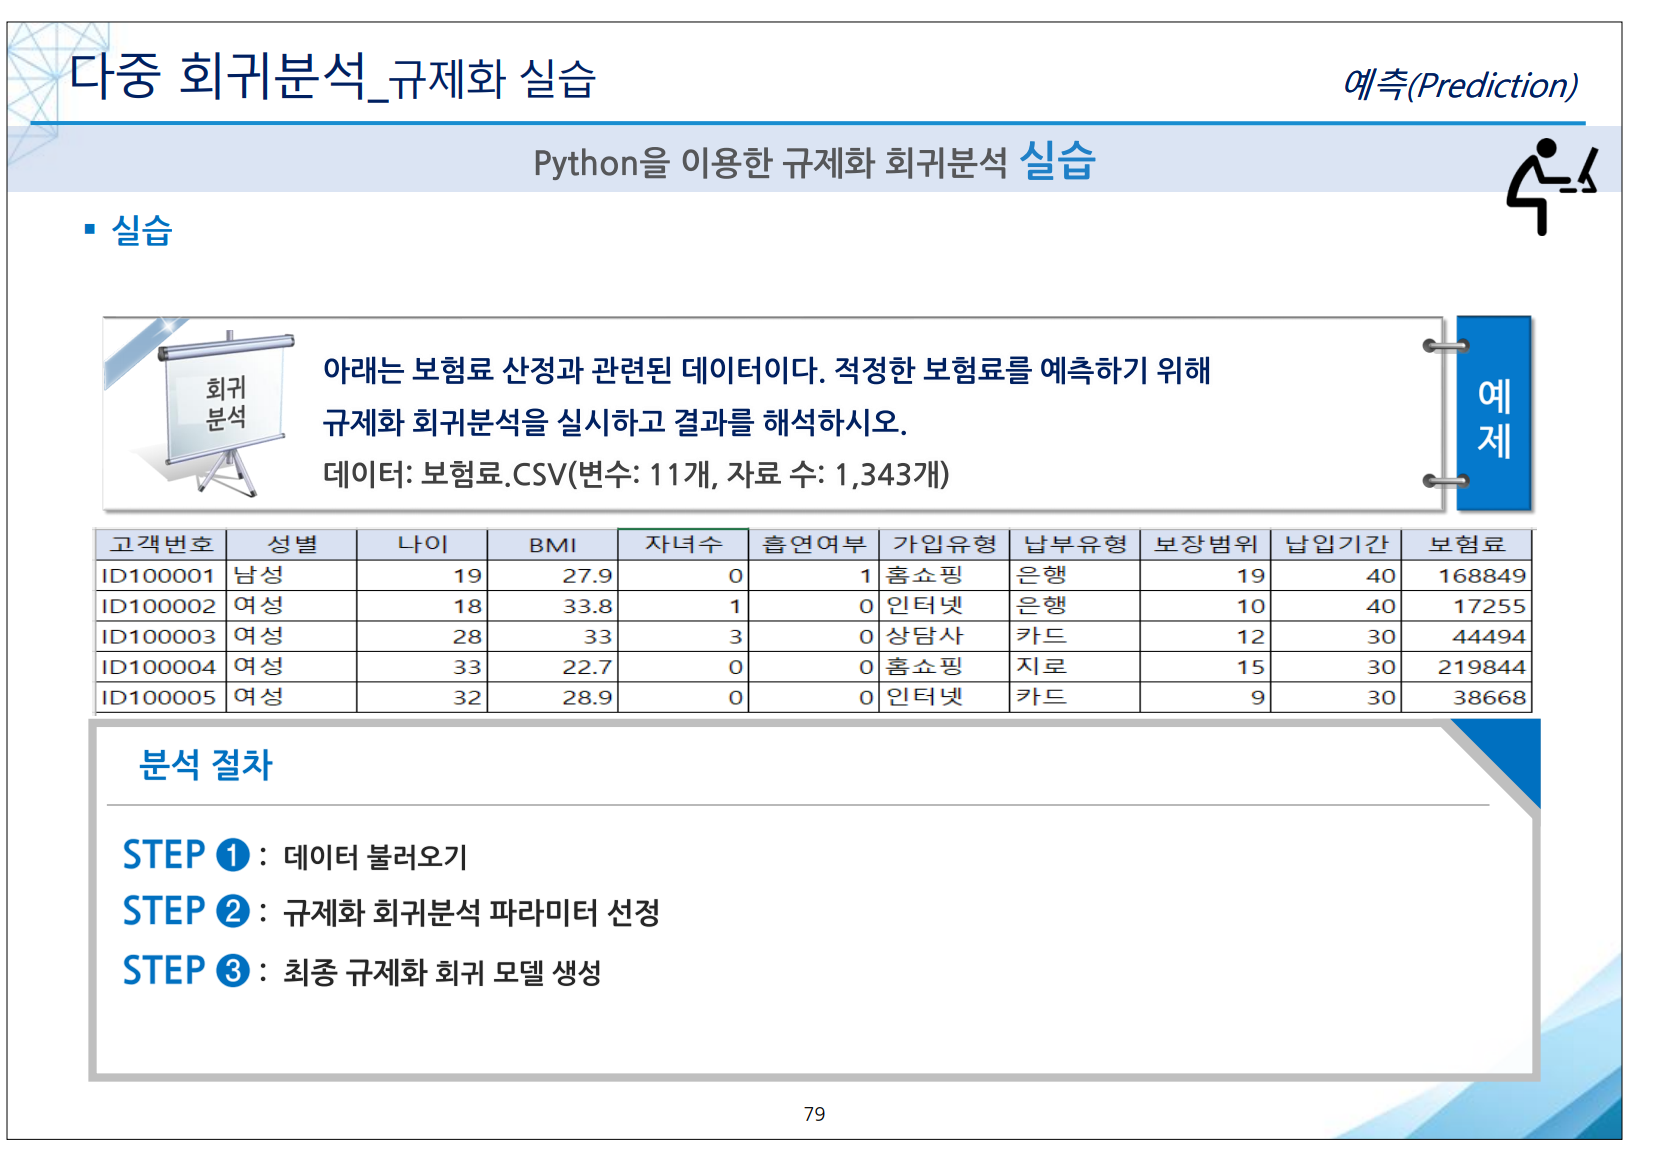

### STEP ❶ : 데이터 불러오기

In [28]:
import matplotlib.pyplot as plt

# Windows 환경에서 가장 일반적인 맑은 고딕 설정
plt.rc('font', family='Malgun Gothic')

# 마이너스 기호가 깨지는 것을 방지
plt.rcParams['axes.unicode_minus'] = False

# [추가] 지저분한 경고 메시지만이라도 끄고 싶을 때
import warnings
warnings.filterwarnings('ignore')

In [29]:
# 실행결과 경고메시지 출력 제외
import warnings

warnings.filterwarnings('ignore')

In [30]:
import pandas as pd
# 학습용/평가용 데이터 분리:train, test
from sklearn.model_selection import train_test_split
# 선형회귀모형
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso, ElasticNet
# 평가함수
from sklearn.metrics import r2_score

In [31]:
# 파일 불러오기
df_raw = pd.read_csv(r"D:\BigData_수업용\yay-20260525T102121Z-3-001\yay\2. Big Data 분석 실습파일\보험료.csv", encoding='euc-kr')
df_raw.head()

,고객번호,성별,나이,BMI,자녀수,흡연여부,가입유형,납부유형,보장범위,납입기간,보험료
0,ID100001,남성,19,27.9,0,1,홈쇼핑,은행,19,40,168849
1,ID100002,여성,18,33.8,1,0,인터넷,은행,10,40,17255
2,ID100003,여성,28,33.0,3,0,상담사,카드,12,30,44494
3,ID100004,여성,33,22.7,0,0,홈쇼핑,지로,15,30,219844
4,ID100005,여성,32,28.9,0,0,인터넷,카드,9,30,38668


데이터를 학습용(Train)과 평가용(Test)으로 분리합니다.  
목표변수 : 보험료

In [40]:
# 범주형 변수 더미화 (성별, 가입유형 등을 0과 1로 변환)
df_raw_dummy = pd.get_dummies(df_raw, drop_first=True)

# 목표변수(y)와 설명변수(x) 데이터 지정
df_raw_y = df_raw_dummy["보험료"]
df_raw_x = df_raw_dummy.drop("보험료", axis = 1)

# 학습용/평가용 데이터 분리 (7:3 비율)
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(
    df_raw_x, df_raw_y, test_size = 0.3, random_state = 1234)

print("train data X size : {}".format(df_train_x.shape))
print("train data Y size : {}".format(df_train_y.shape))
print("test data X size : {}".format(df_test_x.shape))
print("test data Y size : {}".format(df_test_y.shape))

train data X size : (940, 11)
train data Y size : (940,)
test data X size : (403, 11)
test data Y size : (403,)


## STEP 2-1: Ridge 회귀 모델 생성

모든 변수를 살리면서 계수의 크기를 줄여 안정적으로 만듭니다.

train data의 결정계수:  0.8182134778094339
test data의 결정계수:  0.8049961579300159


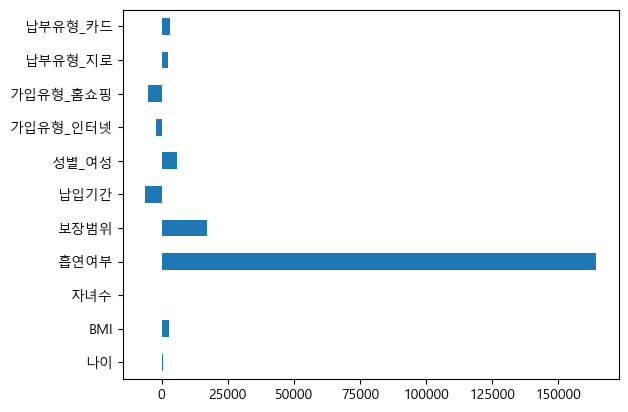

In [33]:
# 모델 생성 및 적합
ridge = Ridge(random_state=1234, alpha = 1)
# 절편값 확인
ridge.fit(df_train_x, df_train_y)

# 회귀계수 확인 및 그래프
df_ridge_coef = pd.DataFrame({"Coef": ridge.coef_}, index = df_train_x.columns)
df_ridge_coef.plot.barh(y = "Coef", legend = False)

# 모델 성능 확인
train_pred = ridge.predict(df_train_x)
test_pred = ridge.predict(df_test_x)
print("train data의 결정계수: ", r2_score(df_train_y, train_pred))
print("test data의 결정계수: ", r2_score(df_test_y, test_pred))

In [41]:
df_ridge_coef = pd.DataFrame({"Coef": ridge.coef_}, index = df_train_x.columns)
df_ridge_coef

,Coef
나이,347.585030
BMI,2704.559956
자녀수,184.055239
흡연여부,164248.181593
보장범위,17039.491806
납입기간,-6180.272438
성별_여성,5639.269745
가입유형_인터넷,-2069.756522
가입유형_홈쇼핑,-5202.696186
납부유형_지로,2555.916936


## STEP 2-2: LASSO 회귀 모델 생성

불필요한 변수의 계수를 0으로 만들어 중요한 변수만 골라냅니다.

train data의 결정계수:  0.8182394265973725
test data의 결정계수:  0.8046442074370032


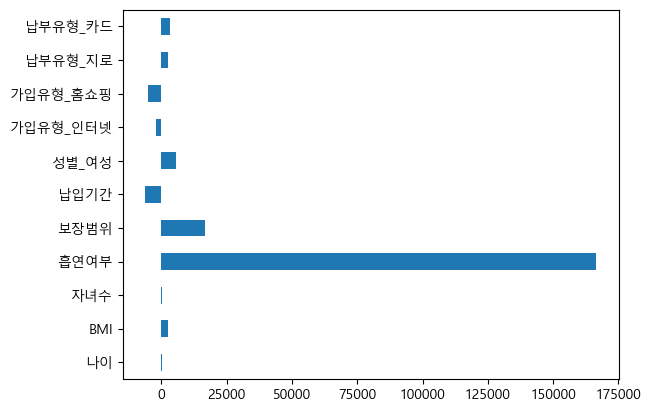

In [54]:
# 모델 생성 및 적합
lasso = Lasso(random_state=1234, alpha = 1)
lasso.fit(df_train_x, df_train_y)

# 회귀계수 확인 및 그래프
df_lasso_coef = pd.DataFrame({"Coef": lasso.coef_}, index = df_train_x.columns)
df_lasso_coef.plot.barh(y = "Coef", legend = False)

# 모델 성능 확인
train_pred = lasso.predict(df_train_x)
test_pred = lasso.predict(df_test_x)
print("train data의 결정계수: ", r2_score(df_train_y, train_pred))
print("test data의 결정계수: ", r2_score(df_test_y, test_pred))

In [ ]:
# 모델 생성
lasso = Lasso(random_state=1234, alpha = 1)
lasso.fit(df_train_x, df_train_y)
# 절편값 확인
print(lasso.intercept_)

-22054.14658117789


In [52]:
# 회귀계수 확인
df_lasso_coef = pd.DataFrame({"Coef": lasso.coef_}, index = df_train_x.columns)
df_lasso_coef

,Coef
나이,358.847372
BMI,2708.378984
자녀수,291.704126
흡연여부,166477.749216
보장범위,16775.782649
납입기간,-6146.040050
성별_여성,5476.552953
가입유형_인터넷,-2044.043158
가입유형_홈쇼핑,-5256.045523
납부유형_지로,2561.011134


### STEP 4: 규제화 회귀모델 생성 (ElasticNet)

Ridge와 Lasso의 장점을 합친 모델입니다.

train data의 결정계수:  0.7105686943591145
test data의 결정계수:  0.7137879807324379


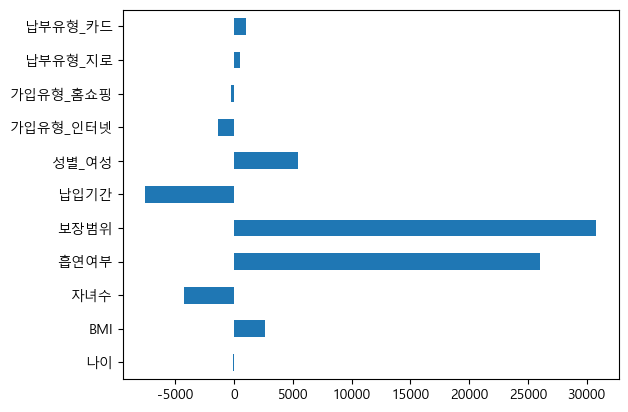

In [35]:
# 모델 생성 및 적합
elastic = ElasticNet(random_state=1234, alpha = 1, l1_ratio = 0.5)
elastic.fit(df_train_x, df_train_y)

# 회귀계수 확인 및 그래프
df_elastic_coef = pd.DataFrame({"Coef": elastic.coef_}, index = df_train_x.columns)
df_elastic_coef.plot.barh(y = "Coef", legend = False)

# 모델 성능 확인
train_pred = elastic.predict(df_train_x)
test_pred = elastic.predict(df_test_x)
print("train data의 결정계수: ", r2_score(df_train_y, train_pred))
print("test data의 결정계수: ", r2_score(df_test_y, test_pred))

In [56]:
# 78 Page
# 모델 생성
elastic = ElasticNet(random_state=1234, alpha = 1, l1_ratio = 0.5)
elastic.fit(df_train_x, df_train_y)
# 절편값 확인
print(elastic.intercept_)

-89083.99513060477


In [57]:
# 회귀계수 확인
df_elastic_coef = pd.DataFrame({"Coef": elastic.coef_}, index = df_train_x.columns)
df_elastic_coef

,Coef
나이,-131.468424
BMI,2603.568797
자녀수,-4222.362535
흡연여부,26051.681620
보장범위,30814.572438
납입기간,-7560.680252
성별_여성,5468.911549
가입유형_인터넷,-1389.977418
가입유형_홈쇼핑,-229.119839
납부유형_지로,508.234009


In [58]:
# 79 Page
# 모델의 성능
train_pred =elastic.predict(df_train_x)
test_pred = elastic.predict(df_test_x)
print("train data의 결정계수:", r2_score(df_train_y, train_pred))
print("test data의 결정계수:", r2_score(df_test_y, test_pred))

train data의 결정계수: 0.7105686943591145
test data의 결정계수: 0.7137879807324379


In [59]:
# 평가용 데이터에 대한 실제값과 예측값 확인(10개 확인)
print('test data의 실제값 : \n', df_test_y[:10])
print('test data의 예측값 : \n', test_pred[:10])

test data의 실제값 : 
 1240    472698
697     402736
324      28660
237      44632
905      45641
535      60671
945     116741
900      86888
411     195948
956     419995
Name: 보험료, dtype: int64
test data의 예측값 : 
 [283970.54985154 262482.54817688  34952.7239042   55175.91267142
 147977.08011173  91977.44949242 180056.74544231  79273.17339948
 182746.43213584 259290.71877182]


### 결론

- 최적의 모델 선정: Ridge 회귀 모델이 테스트 데이터에서 0.8050으로 가장 높은 설명력을 보였습니다. 학습(Train)과 검증(Test) 점수 차이가 거의 없어 과적합(Overfitting) 없이 매우 건강하게 학습된 모델입니다.
- 변수의 영향력: 그래프를 통해 확인한 결과, 보험료에 가장 압도적인 영향을 미치는 변수는 '흡연여부'였습니다. 그다음으로 '보장범위'와 '납입기간'이 주요 변수로 작용했습니다.
- 규제 강도의 적절성: Lasso와 Ridge의 결과가 비슷하다는 것은 현재 설정된 규제 강($alpha=1$)가 데이터의 계수를 0으로 만들 만큼 강하지 않았음을 의미합니다. 반면, 두 방식을 절반씩 섞은 ElasticNet은 오히려 성능이 저하되는 과소적합(Underfitting) 현상이 관찰되었습니다.

### 최종 결론   
실습에서 보험료를 예측하기 위해 규제화 회귀분석을 실시한 결과, Ridge 모델이 가장 우수한 성능을 나타냈습니다.  
전체 변수를 유지하면서 계수의 크기를 조절하는 방식이 보험료 예측에 효과적이었으며, 특히 흡연 여부와 보장 범위가 보험료 산정에 핵심적인 역할을 함을 통계적으로 확인하였습니다.   
향후 모델 고도화를 위해서는 성능이 낮았던 ElasticNet보다는 Ridge 모델을 기반으로 파라미터($alpha$) 튜닝을 진행하는 것이 권장됩니다.

### 